In [2]:
# ============================================================
# Notebook 1 : Dataset Understanding and Exploration
# Dataset : RAVDESS Speech Dataset
# ============================================================

# 1. Import Libraries
import os
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Improve plot style
plt.style.use("seaborn-v0_8")

In [3]:
# ============================================================
# 2. Define Dataset Path
# ============================================================

DATASET_PATH = "../data/raw/Audio_Speech_Actors_01-24"

print("Dataset Path:", DATASET_PATH)

Dataset Path: ../data/raw/Audio_Speech_Actors_01-24


In [4]:
# ============================================================
# 3. Check Dataset Structure
# ============================================================

actors = os.listdir(DATASET_PATH)

print("Total Actor Folders:", len(actors))
print("Sample Actor Folders:", actors[:5])

Total Actor Folders: 24
Sample Actor Folders: ['Actor_01', 'Actor_02', 'Actor_03', 'Actor_04', 'Actor_05']


In [5]:
# ============================================================
# 4. Collect All Audio File Paths
# ============================================================

audio_files = []

for root, dirs, files in os.walk(DATASET_PATH):
    for file in files:
        if file.endswith(".wav"):
            audio_files.append(os.path.join(root, file))

print("Total Audio Files Found:", len(audio_files))

Total Audio Files Found: 1440


In [6]:
# ============================================================
# 5. Display Some Sample Audio File Paths
# ============================================================

for i in range(5):
    print(audio_files[i])

../data/raw/Audio_Speech_Actors_01-24\Actor_01\03-01-01-01-01-01-01.wav
../data/raw/Audio_Speech_Actors_01-24\Actor_01\03-01-01-01-01-02-01.wav
../data/raw/Audio_Speech_Actors_01-24\Actor_01\03-01-01-01-02-01-01.wav
../data/raw/Audio_Speech_Actors_01-24\Actor_01\03-01-01-01-02-02-01.wav
../data/raw/Audio_Speech_Actors_01-24\Actor_01\03-01-02-01-01-01-01.wav


In [7]:
# ============================================================
# 6. Load a Sample Audio File
# ============================================================

sample_file = audio_files[0]

signal, sr = librosa.load(sample_file, sr=None)

print("Sample File:", sample_file)
print("Sampling Rate:", sr)
print("Signal Length:", len(signal))

Sample File: ../data/raw/Audio_Speech_Actors_01-24\Actor_01\03-01-01-01-01-01-01.wav
Sampling Rate: 48000
Signal Length: 158558


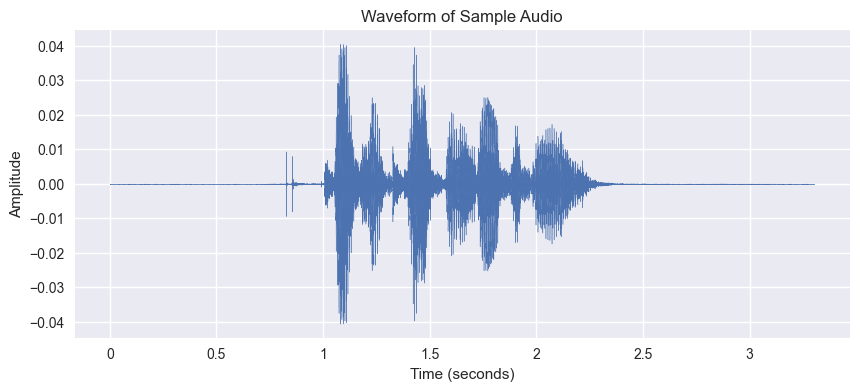

In [8]:
# ============================================================
# 7. Plot Waveform
# ============================================================

plt.figure(figsize=(10,4))

librosa.display.waveshow(signal, sr=sr)

plt.title("Waveform of Sample Audio")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.show()

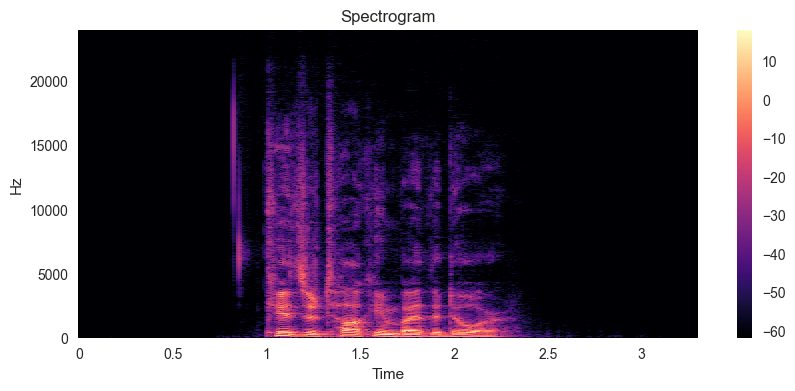

In [9]:
# ============================================================
# 8. Plot Spectrogram
# ============================================================

stft = librosa.stft(signal)

spectrogram = librosa.amplitude_to_db(np.abs(stft))

plt.figure(figsize=(10,4))

librosa.display.specshow(
    spectrogram,
    sr=sr,
    x_axis='time',
    y_axis='hz'
)

plt.colorbar()
plt.title("Spectrogram")

plt.show()

In [10]:
# ============================================================
# 9. Compute Duration of Sample Audio
# ============================================================

duration = librosa.get_duration(y=signal, sr=sr)

print("Audio Duration:", duration, "seconds")

Audio Duration: 3.3032916666666665 seconds


In [11]:
# ============================================================
# 10. Analyze Duration of Multiple Audio Files
# ============================================================

durations = []

for file in audio_files[:50]:
    
    y, sr = librosa.load(file, sr=None)
    
    d = librosa.get_duration(y=y, sr=sr)
    
    durations.append(d)

print("Average Duration:", np.mean(durations))
print("Minimum Duration:", np.min(durations))
print("Maximum Duration:", np.max(durations))

Average Duration: 3.78644875
Minimum Duration: 3.1698333333333335
Maximum Duration: 5.005


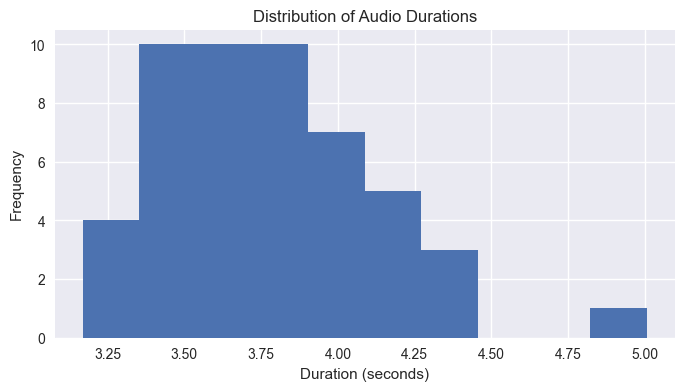

In [12]:
# ============================================================
# 11. Visualize Duration Distribution
# ============================================================

plt.figure(figsize=(8,4))

plt.hist(durations, bins=10)

plt.title("Distribution of Audio Durations")
plt.xlabel("Duration (seconds)")
plt.ylabel("Frequency")

plt.show()

In [13]:
# ============================================================
# 12. Create Dataset Summary Table
# ============================================================

summary = {
    
    "Total Actors": len(actors),
    
    "Total Audio Files": len(audio_files),
    
    "Average Duration (sec)": np.mean(durations),
    
    "Sampling Rate": sr
}

summary_df = pd.DataFrame([summary])

summary_df

,Total Actors,Total Audio Files,Average Duration (sec),Sampling Rate
0,24,1440,3.786449,48000


Dataset Observations

The dataset contains 24 actors.

A total of 1440 audio recordings are available.

The average duration of recordings is approximately 3.78 seconds.

All recordings have a sampling rate of 48 kHz, ensuring high-quality audio.